# APPENDIX A Advanced NumPy
en este apendice se vera en mayor profuncdidad la libreria NumPy para array computing. Esto incluye detalles mas avanzados sobre la manipulación de arrays y algoritmos

In [1]:
# Comandos para que Jupyter evalúe y muestre todas las expresiones de una celda automáticamente
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_columns = 20
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

In [3]:
rng = np.random.default_rng(seed=12345)

In [4]:
np.ones((10, 5)).shape

(10, 5)

In [4]:
np.ones((3, 4, 5), dtype=np.float64).strides

In [4]:
ints = np.ones(10, dtype=np.uint16)
floats = np.ones(10, dtype=np.float32)
np.issubdtype(ints.dtype, np.integer)
np.issubdtype(floats.dtype, np.floating)

True

True

In [5]:
np.float64.mro()

[numpy.float64,
 numpy.floating,
 numpy.inexact,
 numpy.number,
 numpy.generic,
 float,
 object]

In [6]:
np.issubdtype(ints.dtype, np.number)

True

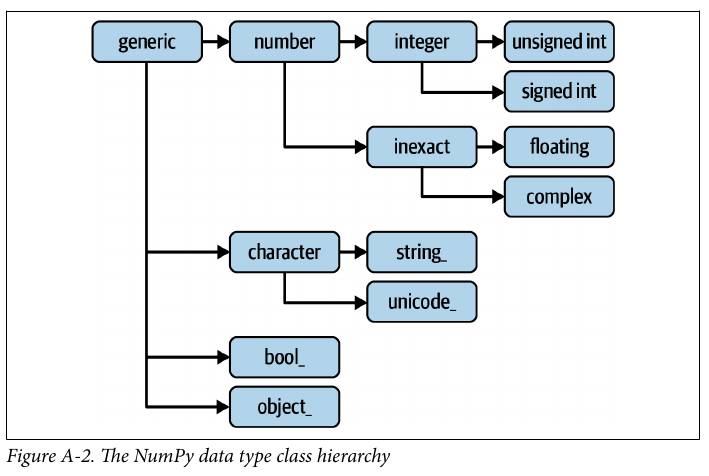

## Reshaping Arrays
In many cases, you can convert an array from one shape to another without copying any data. To do this, pass a tuple indicating the new shape to the reshape array instance method. For example, suppose we had a one-dimensional array of values that we wished to rearrange into a matrix

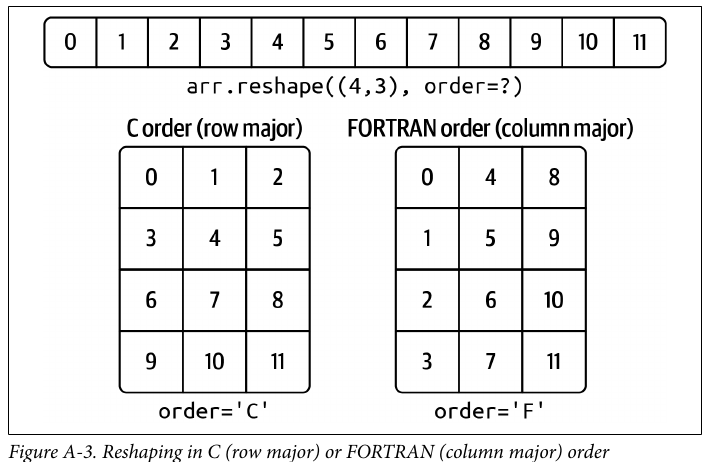

In [7]:
arr = np.arange(8)
arr
arr.reshape((4, 2))

array([0, 1, 2, 3, 4, 5, 6, 7])

array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7]])

In [9]:
# A multidimensional array can also be reshaped:
arr.reshape((4, 2)).reshape((2, 4))

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [10]:
# One of the passed shape dimensions can be –1, in which case the value used for that dimension will be inferred from the data:
arr = np.arange(15)
arr.reshape((5, -1))

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [11]:
other_arr = np.ones((3, 5))
other_arr.shape
arr.reshape(other_arr.shape) # Since an array’s shape attribute is a tuple, it can be passed to reshape

(3, 5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [12]:
arr = np.arange(15).reshape((5, 3))
arr
arr.ravel() # al pasar de varias dimensiones a una selllam flattening or raveling

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [13]:
arr.flatten() # este se comporta igual que el anterior pero devuelve una copia de la data no una referencia

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [14]:
arr = np.arange(12).reshape((3, 4))
arr
arr.ravel() # ordenar por fila
arr.ravel('F') # ordenar por columnas

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

array([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])

In [15]:
arr1 = np.array([[1, 2, 3], [4, 5, 6]])
arr2 = np.array([[7, 8, 9], [10, 11, 12]])
np.concatenate([arr1, arr2], axis=0) # concatena en columnas
np.concatenate([arr1, arr2], axis=1) # concatena en filas

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

array([[ 1,  2,  3,  7,  8,  9],
       [ 4,  5,  6, 10, 11, 12]])

In [16]:
np.vstack((arr1, arr2)) # concatena en columnas
np.hstack((arr1, arr2)) # concatena en filas

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

array([[ 1,  2,  3,  7,  8,  9],
       [ 4,  5,  6, 10, 11, 12]])

In [17]:
arr = rng.standard_normal((5, 2))
arr
first, second, third = np.split(arr, [1, 3]) # split, slices an array into multiple arrays along an axis
first
second
third

array([[-1.4238,  1.2637],
       [-0.8707, -0.2592],
       [-0.0753, -0.7409],
       [-1.3678,  0.6489],
       [ 0.3611, -1.9529]])

array([[-1.4238,  1.2637]])

array([[-0.8707, -0.2592],
       [-0.0753, -0.7409]])

array([[-1.3678,  0.6489],
       [ 0.3611, -1.9529]])

The value [1, 3] passed to np.split indicates the indices at which to split the arrayinto pieces.

### Table 11-6. Rolling or moving window function arguments

| Argument | Description |
| :--- | :--- |
| `window` | Tamaño de la ventana móvil, ya sea como un número de observaciones enteras o como un período de tiempo (como `'20s'`). |
| `min_periods` | Número mínimo de observaciones en una ventana requeridas para tener un valor (de lo contrario, devuelve `NA`); por defecto, el tamaño de la ventana sirve como el mínimo de períodos para una ventana de tamaño entero. |
| `center` | Establecer las etiquetas del resultado en el centro de la ventana; por defecto es `False` (lo que posiciona la etiqueta en el borde derecho). |
| `win_type` | Tipo de ventana de suavizado (como `"gaussian"`); requiere haber importado `scipy`. |
| `on` | Para un DataFrame, columna sobre la cual calcular la ventana móvil, en lugar del índice del DataFrame. |
| `closed` | Establecer los bordes de la ventana como cerrados (`"right"`, `"left"`, `"both"` o `"neither"`); para intervalos de tiempo, por defecto es `"right"`. |
| `step` | Introducido para calcular la ventana móvil en pasos fijos de tamaño entero en lugar de hacerlo en cada fila (por ejemplo, omitiendo filas). |



In [18]:
arr = np.arange(6)
arr1 = arr.reshape((3, 2))
arr2 = rng.standard_normal((3, 2))
np.r_[arr1, arr2]
np.c_[np.r_[arr1, arr2], arr]

array([[ 0.    ,  1.    ],
       [ 2.    ,  3.    ],
       [ 4.    ,  5.    ],
       [ 2.3474,  0.9685],
       [-0.7594,  0.9022],
       [-0.467 , -0.0607]])

array([[ 0.    ,  1.    ,  0.    ],
       [ 2.    ,  3.    ,  1.    ],
       [ 4.    ,  5.    ,  2.    ],
       [ 2.3474,  0.9685,  3.    ],
       [-0.7594,  0.9022,  4.    ],
       [-0.467 , -0.0607,  5.    ]])

In [19]:
np.c_[1:6, -10:-5]

array([[  1, -10],
       [  2,  -9],
       [  3,  -8],
       [  4,  -7],
       [  5,  -6]])

In [20]:
arr = np.arange(3)
arr
arr.repeat(3) #  repeat replicates each element in an array some number of times, producing a larger array

array([0, 1, 2])

array([0, 0, 0, 1, 1, 1, 2, 2, 2])

In [23]:
arr.repeat([2, 3, 4]) # como se pasa un array de integers se repite este valor diferente numero de veces

array([0, 0, 1, 1, 1, 2, 2, 2, 2])

In [26]:
arr = rng.standard_normal((2, 2))
arr
arr.repeat(2) # flattering lo deja en 1D
arr.repeat(2, axis=0) # axis vertical

array([[-0.1582,  0.4495],
       [-1.3436, -0.0817]])

array([-0.1582, -0.1582,  0.4495,  0.4495, -1.3436, -1.3436, -0.0817,
       -0.0817])

array([[-0.1582,  0.4495],
       [-0.1582,  0.4495],
       [-1.3436, -0.0817],
       [-1.3436, -0.0817]])

In [27]:
arr.repeat([2, 3], axis=0)
arr.repeat([2, 3], axis=1)

array([[-0.1582,  0.4495],
       [-0.1582,  0.4495],
       [-1.3436, -0.0817],
       [-1.3436, -0.0817],
       [-1.3436, -0.0817]])

array([[-0.1582, -0.1582,  0.4495,  0.4495,  0.4495],
       [-1.3436, -1.3436, -0.0817, -0.0817, -0.0817]])

Por otro lado, *tile* es un atajo para apilar copias de una matriz a lo largo de un eje. Visualmente, puedes imaginártelo como algo parecido a «colocar baldosas».

El segundo argumento es el número de `tiles`; con un escalar, el `tile` se crea fila por fila, en lugar de columna por columna. El segundo argumento de la función `tile` puede ser una tupla que indique la disposición del «mosaico»:

In [29]:
arr
np.tile(arr, 2)

array([[-0.1582,  0.4495],
       [-1.3436, -0.0817]])

array([[-0.1582,  0.4495, -0.1582,  0.4495],
       [-1.3436, -0.0817, -1.3436, -0.0817]])

In [30]:
arr
np.tile(arr, (2, 1))
np.tile(arr, (3, 2))

array([[-0.1582,  0.4495],
       [-1.3436, -0.0817]])

array([[-0.1582,  0.4495],
       [-1.3436, -0.0817],
       [-0.1582,  0.4495],
       [-1.3436, -0.0817]])

array([[-0.1582,  0.4495, -0.1582,  0.4495],
       [-1.3436, -0.0817, -1.3436, -0.0817],
       [-0.1582,  0.4495, -0.1582,  0.4495],
       [-1.3436, -0.0817, -1.3436, -0.0817],
       [-0.1582,  0.4495, -0.1582,  0.4495],
       [-1.3436, -0.0817, -1.3436, -0.0817]])

In [31]:
arr = np.arange(10) * 100
inds = [7, 1, 2, 6]
arr[inds]

array([700, 100, 200, 600])

In [32]:
arr.take(inds)
arr.put(inds, 42)
arr
arr.put(inds, [40, 41, 42, 43])
arr

array([700, 100, 200, 600])

array([  0,  42,  42, 300, 400, 500,  42,  42, 800, 900])

array([  0,  41,  42, 300, 400, 500,  43,  40, 800, 900])

In [33]:
inds = [2, 0, 2, 1]
arr = rng.standard_normal((2, 4))
arr
arr.take(inds, axis=1)

array([[ 1.7247,  2.6182,  0.7774,  0.8286],
       [-0.959 , -1.2094, -1.4123,  0.5415]])

array([[ 0.7774,  1.7247,  0.7774,  2.6182],
       [-1.4123, -0.959 , -1.4123, -1.2094]])

## A.3 Broadcasting
`Broadcasting` regula el funcionamiento de las operaciones entre matrices de diferentes formas. Puede ser una característica muy útil, pero también puede generar confusión, incluso entre usuarios experimentados. El ejemplo más sencillo de difusión se da al combinar un valor escalar con una matriz.

En este caso, decimos que el valor escalar 4 se ha propagado a todos los demás elementos de la operación de multiplicación.

In [34]:
arr = np.arange(5)
arr
arr * 4

array([0, 1, 2, 3, 4])

array([ 0,  4,  8, 12, 16])

In [36]:
arr = rng.standard_normal((4, 3))
arr.mean(0) # saca la media por columnas
demeaned = arr - arr.mean(0)
demeaned
demeaned.mean(0)

array([-0.1614,  0.0182,  0.0022])

array([[ 0.2226,  0.0527,  0.4315],
       [ 0.4389,  0.512 ,  0.5345],
       [ 0.7798, -0.8133,  0.2978],
       [-1.4413,  0.2486, -1.2638]])

array([0., 0., 0.])

## The Broadcasting Rule
Dos matrices son compatibles para la `broadcasting` si, para cada `trailing dimension` (es decir, empezando por el final), las longitudes de los ejes coinciden o si cualquiera de las longitudes es 1. La difusión se realiza entonces sobre las dimensiones que faltan o aquellas cuya longitud es 1.

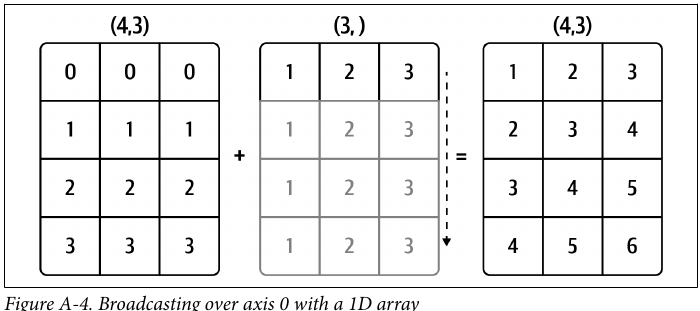

In [37]:
arr
row_means = arr.mean(1) # saca la media por filas
row_means.shape
row_means.reshape((4, 1))
demeaned = arr - row_means.reshape((4, 1))
demeaned.mean(1)

array([[ 0.0611,  0.0709,  0.4337],
       [ 0.2775,  0.5303,  0.5367],
       [ 0.6184, -0.795 ,  0.3   ],
       [-1.6027,  0.2668, -1.2616]])

(4,)

array([[ 0.1886],
       [ 0.4482],
       [ 0.0411],
       [-0.8658]])

array([-0., -0.,  0., -0.])

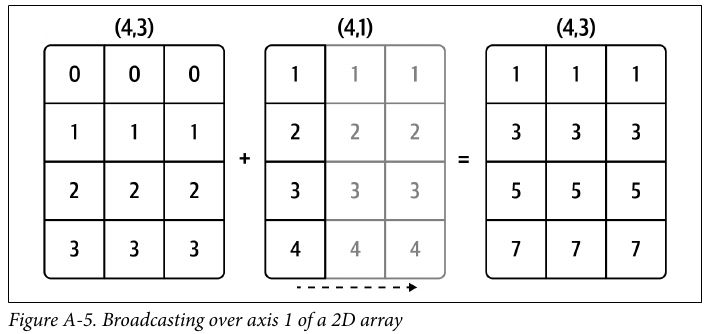

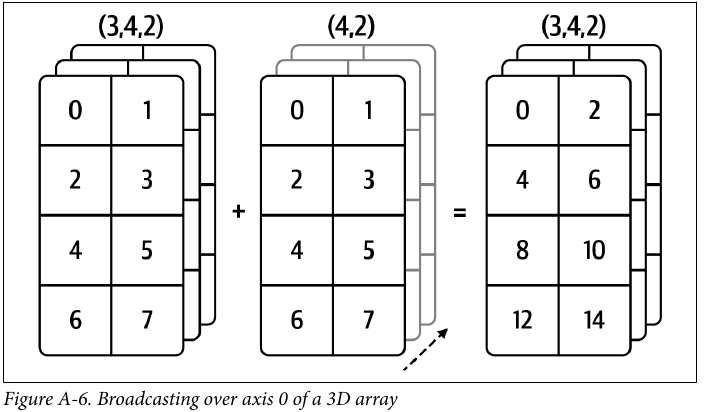

In [38]:
arr - arr.mean(1)

ValueError: operands could not be broadcast together with shapes (4,3) (4,) 

In [39]:
arr - arr.mean(1).reshape((4, 1))

array([[-0.1274, -0.1177,  0.2451],
       [-0.1707,  0.0821,  0.0886],
       [ 0.5772, -0.8361,  0.2589],
       [-0.7369,  1.1326, -0.3958]])

In [40]:
arr = np.zeros((4, 4))
arr
arr_3d = arr[:, np.newaxis, :]
arr_3d
arr_3d.shape
arr_1d = rng.standard_normal(3)
arr_1d[:, np.newaxis]
arr_1d[np.newaxis, :]
arr_1d

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

array([[[0., 0., 0., 0.]],

       [[0., 0., 0., 0.]],

       [[0., 0., 0., 0.]],

       [[0., 0., 0., 0.]]])

(4, 1, 4)

array([[-0.0713],
       [ 0.474 ],
       [-0.4149]])

array([[-0.0713,  0.474 , -0.4149]])

array([-0.0713,  0.474 , -0.4149])

In [41]:
arr = rng.standard_normal((3, 4, 5))
depth_means = arr.mean(2)
depth_means
depth_means.shape
demeaned = arr - depth_means[:, :, np.newaxis]
demeaned.mean(2)

array([[-0.5732, -0.5467,  0.1183, -0.6301],
       [ 0.0972,  0.5954,  0.0331, -0.6002],
       [-0.0808,  0.6847,  0.8522, -0.049 ]])

(3, 4)

array([[ 0., -0., -0., -0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]])

In [42]:
arr = np.zeros((4, 3))
arr[:] = 5 # setting array values by broadcasting
arr

array([[5., 5., 5.],
       [5., 5., 5.],
       [5., 5., 5.],
       [5., 5., 5.]])

In [43]:
col = np.array([1.28, -0.42, 0.44, 1.6])
arr[:] = col[:, np.newaxis]
arr
arr[:2] = [[-1.37], [0.509]]
arr

array([[ 1.28,  1.28,  1.28],
       [-0.42, -0.42, -0.42],
       [ 0.44,  0.44,  0.44],
       [ 1.6 ,  1.6 ,  1.6 ]])

array([[-1.37 , -1.37 , -1.37 ],
       [ 0.509,  0.509,  0.509],
       [ 0.44 ,  0.44 ,  0.44 ],
       [ 1.6  ,  1.6  ,  1.6  ]])

In [44]:
arr = np.arange(10)
np.add.reduce(arr)
arr.sum()

np.int64(45)

np.int64(45)

In [45]:
my_rng = np.random.default_rng(12346)  # for reproducibility
arr = my_rng.standard_normal((5, 5))
arr
arr[::2].sort(1) # sort a few rows
arr
arr[:, :-1] < arr[:, 1:]
np.logical_and.reduce(arr[:, :-1] < arr[:, 1:], axis=1)

array([[-0.9039,  0.1571,  0.8976, -0.7622, -0.1763],
       [ 0.053 , -1.6284, -0.1775,  1.9636,  1.7813],
       [-0.8797, -1.6985, -1.8189,  0.119 , -0.4441],
       [ 0.7691, -0.0343,  0.3925,  0.7589, -0.0705],
       [ 1.0498,  1.0297, -0.4201,  0.7863,  0.9612]])

array([[-0.9039, -0.7622, -0.1763,  0.1571,  0.8976],
       [ 0.053 , -1.6284, -0.1775,  1.9636,  1.7813],
       [-1.8189, -1.6985, -0.8797, -0.4441,  0.119 ],
       [ 0.7691, -0.0343,  0.3925,  0.7589, -0.0705],
       [-0.4201,  0.7863,  0.9612,  1.0297,  1.0498]])

array([[ True,  True,  True,  True],
       [False,  True,  True, False],
       [ True,  True,  True,  True],
       [False,  True,  True, False],
       [ True,  True,  True,  True]])

array([ True, False,  True, False,  True])

In [46]:
arr = np.arange(15).reshape((3, 5))
np.add.accumulate(arr, axis=1)

array([[ 0,  1,  3,  6, 10],
       [ 5, 11, 18, 26, 35],
       [10, 21, 33, 46, 60]])

In [47]:
arr = np.arange(3).repeat([1, 2, 2])
arr
np.multiply.outer(arr, np.arange(5))

array([0, 1, 1, 2, 2])

array([[0, 0, 0, 0, 0],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 2, 4, 6, 8],
       [0, 2, 4, 6, 8]])

In [48]:
x, y = rng.standard_normal((3, 4)), rng.standard_normal(5)
result = np.subtract.outer(x, y)
result.shape

(3, 4, 5)

In [49]:
arr = np.arange(10)
np.add.reduceat(arr, [0, 5, 8])

array([10, 18, 17])

In [50]:
arr = np.multiply.outer(np.arange(4), np.arange(5))
arr
np.add.reduceat(arr, [0, 2, 4], axis=1)

array([[ 0,  0,  0,  0,  0],
       [ 0,  1,  2,  3,  4],
       [ 0,  2,  4,  6,  8],
       [ 0,  3,  6,  9, 12]])

array([[ 0,  0,  0],
       [ 1,  5,  4],
       [ 2, 10,  8],
       [ 3, 15, 12]])

In [51]:
def add_elements(x, y):
    return x + y
add_them = np.frompyfunc(add_elements, 2, 1)
add_them(np.arange(8), np.arange(8))

array([0, 2, 4, 6, 8, 10, 12, 14], dtype=object)

In [52]:
add_them = np.vectorize(add_elements, otypes=[np.float64])
add_them(np.arange(8), np.arange(8))

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14.])

In [53]:
arr = rng.standard_normal(10000)
%timeit add_them(arr, arr)
%timeit np.add(arr, arr)

1.05 ms ± 12.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.82 μs ± 26.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [54]:
dtype = [('x', np.float64), ('y', np.int32)]
sarr = np.array([(1.5, 6), (np.pi, -2)], dtype=dtype)
sarr

array([(1.5   ,  6), (3.1416, -2)], dtype=[('x', '<f8'), ('y', '<i4')])

In [55]:
sarr[0]
sarr[0]['y']

np.void((1.5, 6), dtype=[('x', '<f8'), ('y', '<i4')])

np.int32(6)

In [56]:
sarr['x']

array([1.5   , 3.1416])

In [57]:
dtype = [('x', np.int64, 3), ('y', np.int32)]
arr = np.zeros(4, dtype=dtype)
arr

array([([0, 0, 0], 0), ([0, 0, 0], 0), ([0, 0, 0], 0), ([0, 0, 0], 0)],
      dtype=[('x', '<i8', (3,)), ('y', '<i4')])

In [58]:
arr[0]['x']

array([0, 0, 0])

In [59]:
arr['x']

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]])

In [60]:
dtype = [('x', [('a', 'f8'), ('b', 'f4')]), ('y', np.int32)]
data = np.array([((1, 2), 5), ((3, 4), 6)], dtype=dtype)
data['x']
data['y']
data['x']['a']

array([(1., 2.), (3., 4.)], dtype=[('a', '<f8'), ('b', '<f4')])

array([5, 6], dtype=int32)

array([1., 3.])

In [61]:
arr = rng.standard_normal(6)
arr.sort()
arr

array([-1.1704, -0.796 , -0.2686,  0.5026,  0.8981,  1.4522])

In [62]:
arr = rng.standard_normal((3, 5))
arr
arr[:, 0].sort()  # Sort first column values in place
arr

array([[-0.2535,  2.1183,  0.3634, -0.6245,  1.1279],
       [ 1.6164, -0.2287, -0.6201, -0.1143, -1.2067],
       [-1.0872, -2.1518, -0.6287, -1.3199,  0.083 ]])

array([[-1.0872,  2.1183,  0.3634, -0.6245,  1.1279],
       [-0.2535, -0.2287, -0.6201, -0.1143, -1.2067],
       [ 1.6164, -2.1518, -0.6287, -1.3199,  0.083 ]])

In [63]:
arr = rng.standard_normal(5)
arr
np.sort(arr)
arr

array([ 0.2017,  0.9173,  0.1764, -0.2934,  1.1621])

array([-0.2934,  0.1764,  0.2017,  0.9173,  1.1621])

array([ 0.2017,  0.9173,  0.1764, -0.2934,  1.1621])

In [64]:
arr = rng.standard_normal((3, 5))
arr
arr.sort(axis=1)
arr

array([[-0.7503, -2.1268, -1.391 , -0.4922,  0.4505],
       [ 0.8926, -1.0479,  0.9553,  0.2936,  0.5379],
       [-1.0512, -0.3045, -2.1392,  0.0097, -0.4434]])

array([[-2.1268, -1.391 , -0.7503, -0.4922,  0.4505],
       [-1.0479,  0.2936,  0.5379,  0.8926,  0.9553],
       [-2.1392, -1.0512, -0.4434, -0.3045,  0.0097]])

In [65]:
arr[:, ::-1]

array([[ 0.4505, -0.4922, -0.7503, -1.391 , -2.1268],
       [ 0.9553,  0.8926,  0.5379,  0.2936, -1.0479],
       [ 0.0097, -0.3045, -0.4434, -1.0512, -2.1392]])

In [66]:
values = np.array([5, 0, 1, 3, 2])
indexer = values.argsort()
indexer
values[indexer]

array([1, 2, 4, 3, 0])

array([0, 1, 2, 3, 5])

In [67]:
arr = rng.standard_normal((3, 5))
arr[0] = values
arr
arr[:, arr[0].argsort()]

array([[ 5.    ,  0.    ,  1.    ,  3.    ,  2.    ],
       [-0.3361,  1.7394, -0.8178, -1.4429, -0.042 ],
       [ 1.6032,  0.4547, -1.7277, -0.5546,  1.1287]])

array([[ 0.    ,  1.    ,  2.    ,  3.    ,  5.    ],
       [ 1.7394, -0.8178, -0.042 , -1.4429, -0.3361],
       [ 0.4547, -1.7277,  1.1287, -0.5546,  1.6032]])

In [68]:
first_name = np.array(['Bob', 'Jane', 'Steve', 'Bill', 'Barbara'])
last_name = np.array(['Jones', 'Arnold', 'Arnold', 'Jones', 'Walters'])
sorter = np.lexsort((first_name, last_name))
sorter
list(zip(last_name[sorter], first_name[sorter]))

array([1, 2, 3, 0, 4])

[(np.str_('Arnold'), np.str_('Jane')),
 (np.str_('Arnold'), np.str_('Steve')),
 (np.str_('Jones'), np.str_('Bill')),
 (np.str_('Jones'), np.str_('Bob')),
 (np.str_('Walters'), np.str_('Barbara'))]

In [69]:
values = np.array(['2:first', '2:second', '1:first', '1:second',
                   '1:third'])
key = np.array([2, 2, 1, 1, 1])
indexer = key.argsort(kind='mergesort')
indexer
values.take(indexer)

array([2, 3, 4, 0, 1])

array(['1:first', '1:second', '1:third', '2:first', '2:second'],
      dtype='<U8')

In [70]:
rng = np.random.default_rng(12345)
arr = rng.standard_normal(20)
arr
np.partition(arr, 3)

array([-1.4238,  1.2637, -0.8707, -0.2592, -0.0753, -0.7409, -1.3678,
        0.6489,  0.3611, -1.9529,  2.3474,  0.9685, -0.7594,  0.9022,
       -0.467 , -0.0607,  0.7888, -1.2567,  0.5759,  1.399 ])

array([-1.9529, -1.4238, -1.3678, -1.2567, -0.8707, -0.7594, -0.7409,
       -0.467 , -0.2592, -0.0753, -0.0607,  0.3611,  0.5759,  0.6489,
        0.7888,  0.9022,  0.9685,  1.2637,  1.399 ,  2.3474])

In [71]:
indices = np.argpartition(arr, 3)
indices
arr.take(indices)

array([ 9,  0,  6, 17,  2, 12,  5, 14,  3,  4, 15,  8, 18,  7, 16, 13, 11,
        1, 19, 10])

array([-1.9529, -1.4238, -1.3678, -1.2567, -0.8707, -0.7594, -0.7409,
       -0.467 , -0.2592, -0.0753, -0.0607,  0.3611,  0.5759,  0.6489,
        0.7888,  0.9022,  0.9685,  1.2637,  1.399 ,  2.3474])

## numpy.searchsorted: Finding Elements in a Sorted Array
`searchsorted` is an array method that performs a binary search on a sorted array, returning the location in the array where the value would need to be inserted to maintain sortedness.

In [72]:
arr = np.array([0, 1, 7, 12, 15])
arr.searchsorted(9)

np.int64(3)

In [73]:
arr.searchsorted([0, 8, 11, 16])

array([0, 3, 3, 5])

In [74]:
arr = np.array([0, 0, 0, 1, 1, 1, 1])
arr.searchsorted([0, 1]) # normalmente el siempre devulve la primera pocisión a la izq 
arr.searchsorted([0, 1], side='right')

array([0, 3])

array([3, 7])

In [75]:
data = np.floor(rng.uniform(0, 10000, size=50))
bins = np.array([0, 100, 1000, 5000, 10000])
data

array([ 815., 1598., 3401., 4651., 2664., 8157., 1932., 1294.,  916.,
       5985., 8547., 6016., 9319., 7247., 8605., 9293., 5461., 9376.,
       4949., 2737., 4517., 6650., 3308., 9034., 2570., 3398., 2588.,
       3554.,   50., 6286., 2823.,  680., 6168., 1763., 3043., 4408.,
       1502., 2179., 4743., 4763., 2552., 2975., 2790., 2605., 4827.,
       2119., 4956., 2462., 8384., 1801.])

In [76]:
labels = bins.searchsorted(data)
labels

array([2, 3, 3, 3, 3, 4, 3, 3, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 4,
       3, 4, 3, 3, 3, 3, 1, 4, 3, 2, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 3])

In [77]:
pd.Series(data).groupby(labels).mean()

1      50.000000
2     803.666667
3    3079.741935
4    7635.200000
dtype: float64

In [78]:
import numpy as np

def mean_distance(x, y):
    nx = len(x)
    result = 0.0
    count = 0
    for i in range(nx):
        result += x[i] - y[i]
        count += 1
    return result / count

In [80]:
x = rng.standard_normal(10_000_000)
y = rng.standard_normal(10_000_000)
%timeit mean_distance(x, y)
%timeit (x - y).mean()

1.92 s ± 13.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
27.7 ms ± 730 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## A.7 Writing Fast NumPy Functions with Numba
Numba is an open source project that creates fast functions for NumPy-like data using CPUs, GPUs, or other hardware. It uses the LLVM Project to translate Python code into compiled machine code.

To introduce Numba, let’s consider a pure Python function that computes the expression (x - y).mean() using a for loop.

In [82]:
conda install numba

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\ferch\anaconda3\envs\pydata-book

  added / updated specs:
    - numba


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    llvmlite-0.47.0            |  py310hfe4b161_1        21.8 MB  conda-forge
    numba-0.65.1               |  py310h04bad52_1         4.2 MB  conda-forge
    ------------------------------------------------------------
                                           Total:        26.0 MB

The following NEW packages will be INSTALLED:

  llvmlite           conda-forge/win-64::llvmlite-0.47.0-py310hfe4b161_1 
  numba              conda-forge/win-64::numba-0.65.1-py310h04bad52_1 



llvmlite-0.47.0      | 21.8 MB   |            |   0% 

numba-0.65.1         | 4.2 MB  



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




In [83]:
import numba as nb
numba_mean_distance = nb.jit(mean_distance)

@nb.jit
def numba_mean_distance(x, y):
    nx = len(x)
    result = 0.0
    count = 0
    for i in range(nx):
        result += x[i] - y[i]
        count += 1
    return result / count

In [84]:
%timeit numba_mean_distance(x, y)

7.53 ms ± 78 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Creating Custom numpy.ufunc Objects with Numba
The numba.vectorize function creates compiled NumPy ufuncs, which behave like built-in ufuncs. Let’s consider a Python implementation of numpy.add:

In [85]:
from numba import vectorize

@vectorize
def nb_add(x, y):
    return x + y

x = np.arange(10)

nb_add(x, x)

nb_add.accumulate(x, 0)

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

array([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

In [87]:
section = mmap[:5]

In [88]:
section[:] = rng.standard_normal((5, 10000))
mmap.flush()
mmap
del mmap

memmap([[ 0.8726, -0.439 ,  0.361 , ..., -0.5822,  1.773 , -0.0615],
        [ 0.1979,  2.5442,  0.9167, ...,  0.1741,  0.8364, -0.6414],
        [-0.8671,  1.3508,  0.0072, ...,  0.0877,  1.7929, -2.0398],
        ...,
        [ 0.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ]],
       shape=(10000, 10000))

In [89]:
mmap = np.memmap('mymmap', dtype='float64', shape=(10000, 10000))
mmap

memmap([[ 0.8726, -0.439 ,  0.361 , ..., -0.5822,  1.773 , -0.0615],
        [ 0.1979,  2.5442,  0.9167, ...,  0.1741,  0.8364, -0.6414],
        [-0.8671,  1.3508,  0.0072, ...,  0.0877,  1.7929, -2.0398],
        ...,
        [ 0.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ]],
       shape=(10000, 10000))

In [90]:
%xdel mmap
!rm mymmap

'rm' is not recognized as an internal or external command,
operable program or batch file.


## A.9 Consejos de rendimiento
Adaptar el código de procesamiento de datos para utilizar NumPy suele acelerar considerablemente el proceso, ya que las operaciones con matrices suelen sustituir a los bucles de Python puro, que, en comparación, son extremadamente lentos. A continuación se ofrecen algunos consejos para sacar el máximo partido a la biblioteca:

* Convierte los bucles y la lógica condicional de Python en operaciones con matrices y operaciones con matrices booleanas.
* Utiliza la difusión siempre que sea posible.
* Utiliza vistas de matrices (slicing) para evitar copiar datos.
* Aprovecha las ufuncs y los métodos ufunc.

Si no consigues el rendimiento que necesitas tras agotar las capacidades que ofrece NumPy por sí solo, plantéate escribir código en C, FORTRAN o Cython. Yo utilizo Cython con frecuencia en mi propio trabajo como forma de obtener un rendimiento similar al de C, a menudo con mucho menos tiempo de desarrollo.

In [91]:
arr_c = np.ones((100, 10000), order='C')
arr_f = np.ones((100, 10000), order='F')
arr_c.flags
arr_f.flags
arr_f.flags.f_contiguous

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

  C_CONTIGUOUS : False
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

True

In [92]:
%timeit arr_c.sum(1)
%timeit arr_f.sum(1)

248 μs ± 2.84 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
203 μs ± 1.34 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [93]:
arr_f.copy('C').flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [94]:
arr_c[:50].flags.contiguous
arr_c[:, :50].flags

True

  C_CONTIGUOUS : False
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [82]:
%xdel arr_c
%xdel arr_f

In [84]:
pd.options.display.max_rows = PREVIOUS_MAX_ROWS